# CS3807 — Deep Learning Laboratory
## Experiment 4: Transfer Learning with ResNet50 on CIFAR-10

This notebook implements only the ResNet50 portion of Experiment 4. It includes:
- CIFAR-10 dataset preparation and sample visualization
- ImageNet-pretrained ResNet50 transfer learning
- Frozen-base training
- Lightweight fine-tuning of the last convolutional block
- Accuracy/loss plots
- Test accuracy, macro precision, recall and F1-score
- Confusion matrix and sample misclassified images
- A small, compute-conscious hyperparameter study

**Important:** The CIFAR-10 test set is kept separate from hyperparameter selection. A validation split is taken from the original training set.

In [2]:
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.datasets import cifar10
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 1. Configuration

The configuration is intentionally modest for Kaggle. ResNet50 is computationally expensive on CIFAR-10, so the notebook uses a 32×32-to-128×128 resize rather than unnecessarily using 224×224 images. This retains more spatial information than the original 32×32 setup while keeping compute substantially lower than full ImageNet resolution.

In [3]:
# Dataset / training configuration
IMG_SIZE = 128
BATCH_SIZE = 64
NUM_CLASSES = 10
HEAD_EPOCHS = 8
FINETUNE_EPOCHS = 4
FINE_TUNE_LAYERS = 10
HEAD_LR = 1e-3
FINETUNE_LR = 1e-4
VAL_SIZE = 5000

CLASS_NAMES = [
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
    'Dog', 'Frog', 'Horse', 'Ship', 'Truck'
]

AUTOTUNE = tf.data.AUTOTUNE

## 2. Load and Prepare CIFAR-10

The original CIFAR-10 test set is not used as the validation set. Instead, 5,000 images are held out from the training set for validation. ResNet50's ImageNet preprocessing is applied after resizing.

In [4]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = cifar10.load_data()

y_train_raw = y_train_raw.squeeze().astype(np.int32)
y_test_raw = y_test_raw.squeeze().astype(np.int32)

# Fixed validation split from the training set.
x_val_raw = x_train_raw[-VAL_SIZE:]
y_val = y_train_raw[-VAL_SIZE:]
x_train_raw = x_train_raw[:-VAL_SIZE]
y_train = y_train_raw[:-VAL_SIZE]

print('Training:', x_train_raw.shape, y_train.shape)
print('Validation:', x_val_raw.shape, y_val.shape)
print('Test:', x_test_raw.shape, y_test_raw.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1767s 10us/step
Training: (45000, 32, 32, 3) (45000,)
Validation: (5000, 32, 32, 3) (5000,)
Test: (10000, 32, 32, 3) (10000,)


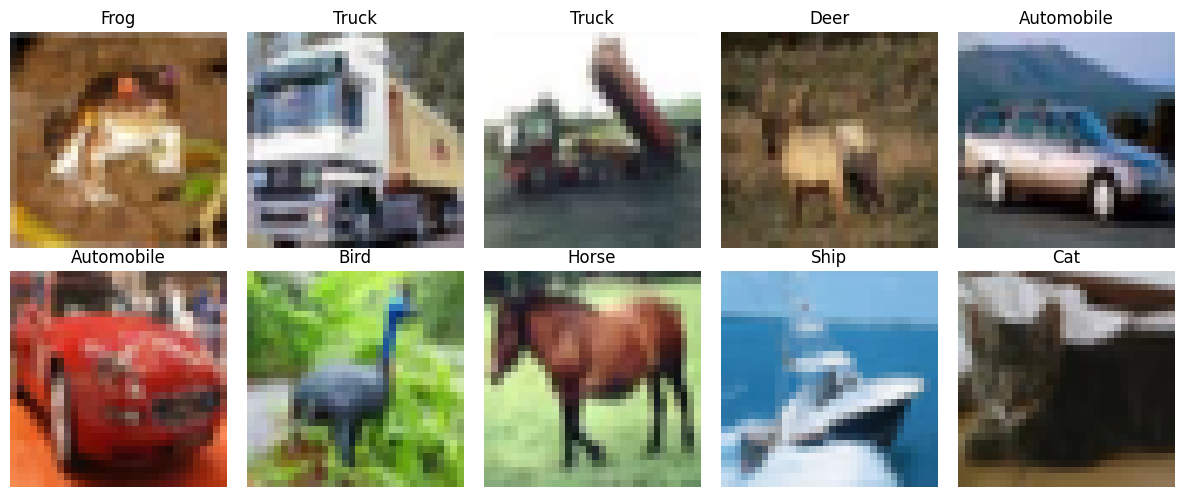

In [5]:
# Display ten sample images for the report.
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train_raw[i])
    ax.set_title(CLASS_NAMES[y_train[i]])
    ax.axis('off')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=180, bbox_inches='tight')
plt.show()

## 3. Efficient Input Pipeline

Images are resized to 128×128 and passed through `ResNet50`'s ImageNet preprocessing. The pipeline uses batching and prefetching to reduce input overhead.

In [6]:
def make_dataset(images, labels, training=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))

    if training:
        ds = ds.shuffle(10000, seed=SEED, reshuffle_each_iteration=True)

    def preprocess_batch(image, label):
        image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE), antialias=True)
        image = tf.cast(image, tf.float32)
        image = preprocess_input(image)
        return image, tf.one_hot(label, NUM_CLASSES)

    ds = ds.map(preprocess_batch, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(x_train_raw, y_train, training=True)
val_ds = make_dataset(x_val_raw, y_val, training=False)
test_ds = make_dataset(x_test_raw, y_test_raw, training=False)

print('Input pipeline ready.')

I0000 00:00:1788068499.283554      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788068499.286457      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Input pipeline ready.


## 4. Build the ResNet50 Transfer-Learning Model

The ImageNet classifier is removed. A Global Average Pooling layer, a 256-unit ReLU Dense layer, and a 10-class Softmax output layer are added for CIFAR-10. The ResNet50 convolutional base is initially frozen.

In [7]:
def build_model():
    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model, base

model, base_model = build_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=HEAD_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print('Total parameters:', model.count_params())
print('Trainable parameters:', np.sum([np.prod(v.shape) for v in model.trainable_weights]))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Total parameters: 24114826
Trainable parameters: 527114


## 5. Train the Frozen ResNet50 Base

Only the new classifier head is trained in this phase. Early stopping restores the best validation model, preventing unnecessary computation.

In [8]:
callbacks_head = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=2,
        mode='max',
        restore_best_weights=True,
        verbose=1
    )
]

start_head = time.time()
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=HEAD_EPOCHS,
    callbacks=callbacks_head,
    verbose=1
)
head_time = time.time() - start_head

print(f'Frozen-base training time: {head_time/60:.2f} minutes')

Epoch 1/8
  3/704 ━━━━━━━━━━━━━━━━━━━━ 35s 51ms/step - accuracy: 0.1319 - loss: 3.4851 

I0000 00:00:1788068519.828415     130 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 71ms/step - accuracy: 0.8555 - loss: 0.4289 - val_accuracy: 0.8712 - val_loss: 0.3619
Epoch 2/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.9006 - loss: 0.2816 - val_accuracy: 0.8840 - val_loss: 0.3359
Epoch 3/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.9233 - loss: 0.2186 - val_accuracy: 0.8766 - val_loss: 0.3683
Epoch 4/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.9399 - loss: 0.1699 - val_accuracy: 0.8918 - val_loss: 0.3344
Epoch 5/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.9545 - loss: 0.1292 - val_accuracy: 0.8870 - val_loss: 0.3513
Epoch 6/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.9631 - loss: 0.0999 - val_accuracy: 0.8878 - val_loss: 0.4137
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 4.
Frozen-base training time: 4.69 minutes


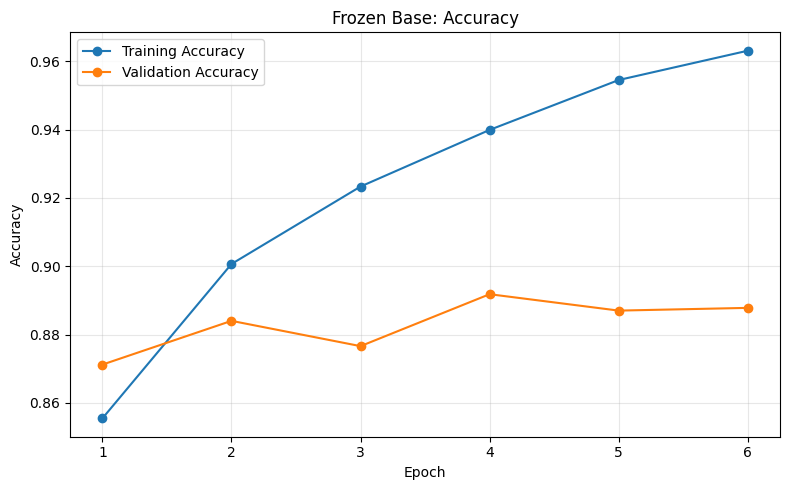

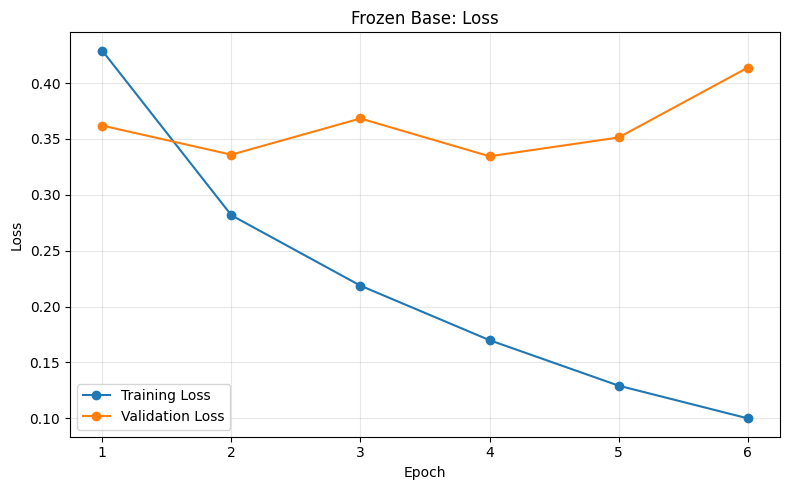

In [9]:
def plot_history(history, title_prefix, accuracy_file, loss_file):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, acc, marker='o', label='Training Accuracy')
    plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'{title_prefix}: Accuracy')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(accuracy_file, dpi=180, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, loss, marker='o', label='Training Loss')
    plt.plot(epochs, val_loss, marker='o', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{title_prefix}: Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(loss_file, dpi=180, bbox_inches='tight')
    plt.show()

plot_history(
    history_head,
    'Frozen Base',
    'accuracy_plot.png',
    'loss_plot.png'
)

## 6. Fine-Tuning

The final few ResNet50 layers are unfrozen and trained with a smaller learning rate. Batch Normalization layers remain frozen to avoid destabilizing their pretrained statistics during fine-tuning.

In [10]:
base_model.trainable = True

# Freeze all but the final few layers of the ResNet50 base.
for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

# Keep BatchNorm statistics/parameters frozen for stable fine-tuning.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable_count = np.sum([np.prod(v.shape) for v in model.trainable_weights])
print('Trainable parameters during fine-tuning:', trainable_count)

Trainable parameters during fine-tuning: 4986634


In [11]:
callbacks_ft = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=2,
        mode='max',
        restore_best_weights=True,
        verbose=1
    )
]

start_ft = time.time()
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=callbacks_ft,
    verbose=1
)
finetune_time = time.time() - start_ft

print(f'Fine-tuning time: {finetune_time/60:.2f} minutes')

Epoch 1/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 71s 84ms/step - accuracy: 0.9569 - loss: 0.1279 - val_accuracy: 0.9036 - val_loss: 0.2833
Epoch 2/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 69ms/step - accuracy: 0.9858 - loss: 0.0514 - val_accuracy: 0.9070 - val_loss: 0.3016
Epoch 3/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 70ms/step - accuracy: 0.9947 - loss: 0.0235 - val_accuracy: 0.9050 - val_loss: 0.3576
Epoch 4/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 69ms/step - accuracy: 0.9977 - loss: 0.0134 - val_accuracy: 0.9082 - val_loss: 0.3384
Restoring model weights from the end of the best epoch: 4.
Fine-tuning time: 3.64 minutes


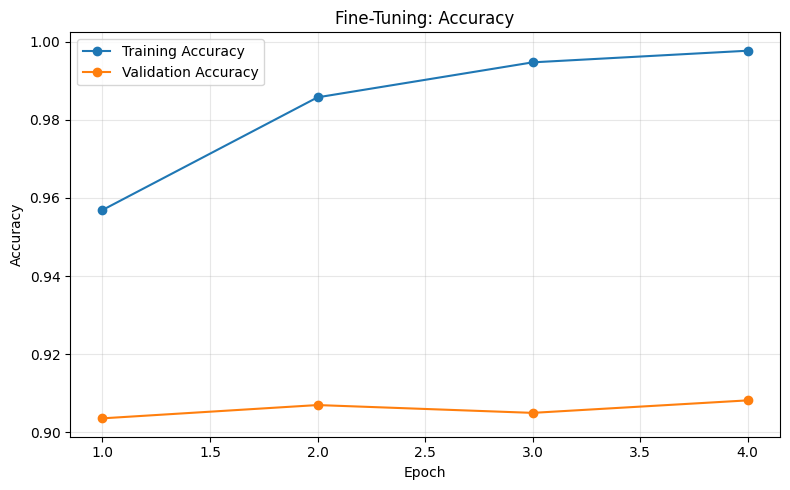

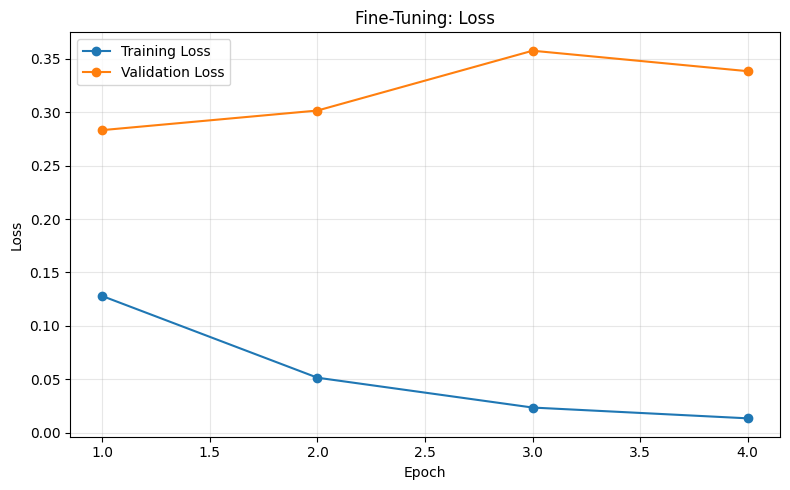

In [12]:
plot_history(
    history_ft,
    'Fine-Tuning',
    'finetune_accuracy_plot.png',
    'finetune_loss_plot.png'
)

## 7. Final Test Evaluation

The test set is evaluated only after model selection and fine-tuning are complete. Precision, recall and F1-score below use **macro averaging**, matching the metric calculation used for the report.

In [13]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

probabilities = model.predict(test_ds, verbose=1)
y_pred = np.argmax(probabilities, axis=1)
y_true = y_test_raw

precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy*100:.2f}%')
print(f'Macro Precision: {precision_macro:.4f}')
print(f'Macro Recall: {recall_macro:.4f}')
print(f'Macro F1-score: {f1_macro:.4f}')

157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.9067 - loss: 0.3570
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step
Test Loss: 0.3570
Test Accuracy: 90.67%
Macro Precision: 0.9076
Macro Recall: 0.9067
Macro F1-score: 0.9069


In [14]:
print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

    Airplane     0.9376    0.9170    0.9272      1000
  Automobile     0.9228    0.9560    0.9391      1000
        Bird     0.9246    0.8830    0.9033      1000
         Cat     0.8213    0.8270    0.8241      1000
        Deer     0.8545    0.9100    0.8814      1000
         Dog     0.8483    0.8610    0.8546      1000
        Frog     0.9379    0.9360    0.9369      1000
       Horse     0.9480    0.9110    0.9291      1000
        Ship     0.9282    0.9570    0.9424      1000
       Truck     0.9528    0.9090    0.9304      1000

    accuracy                         0.9067     10000
   macro avg     0.9076    0.9067    0.9069     10000
weighted avg     0.9076    0.9067    0.9069     10000



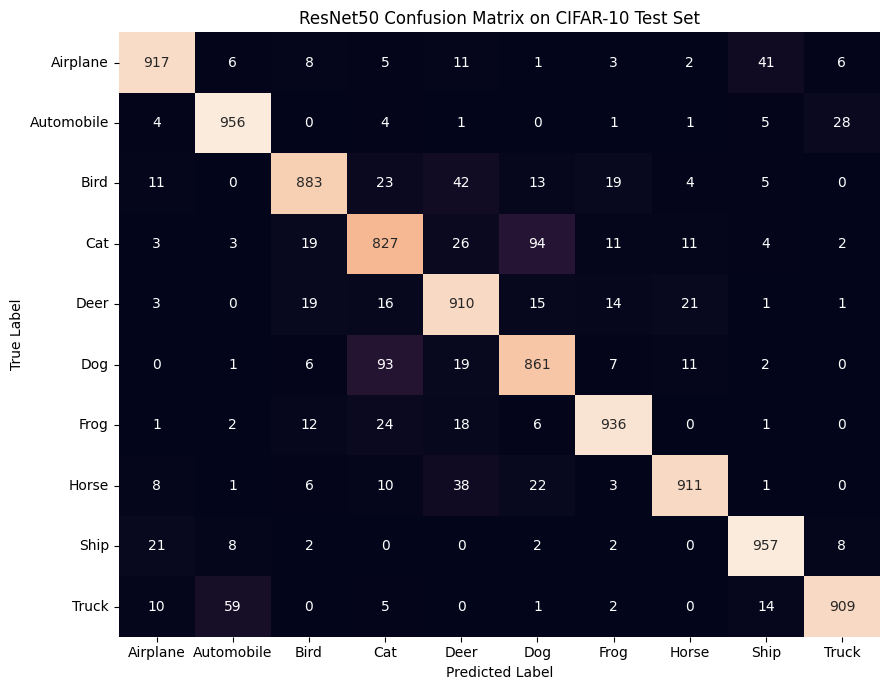

In [15]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar=False
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('ResNet50 Confusion Matrix on CIFAR-10 Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=180, bbox_inches='tight')
plt.show()

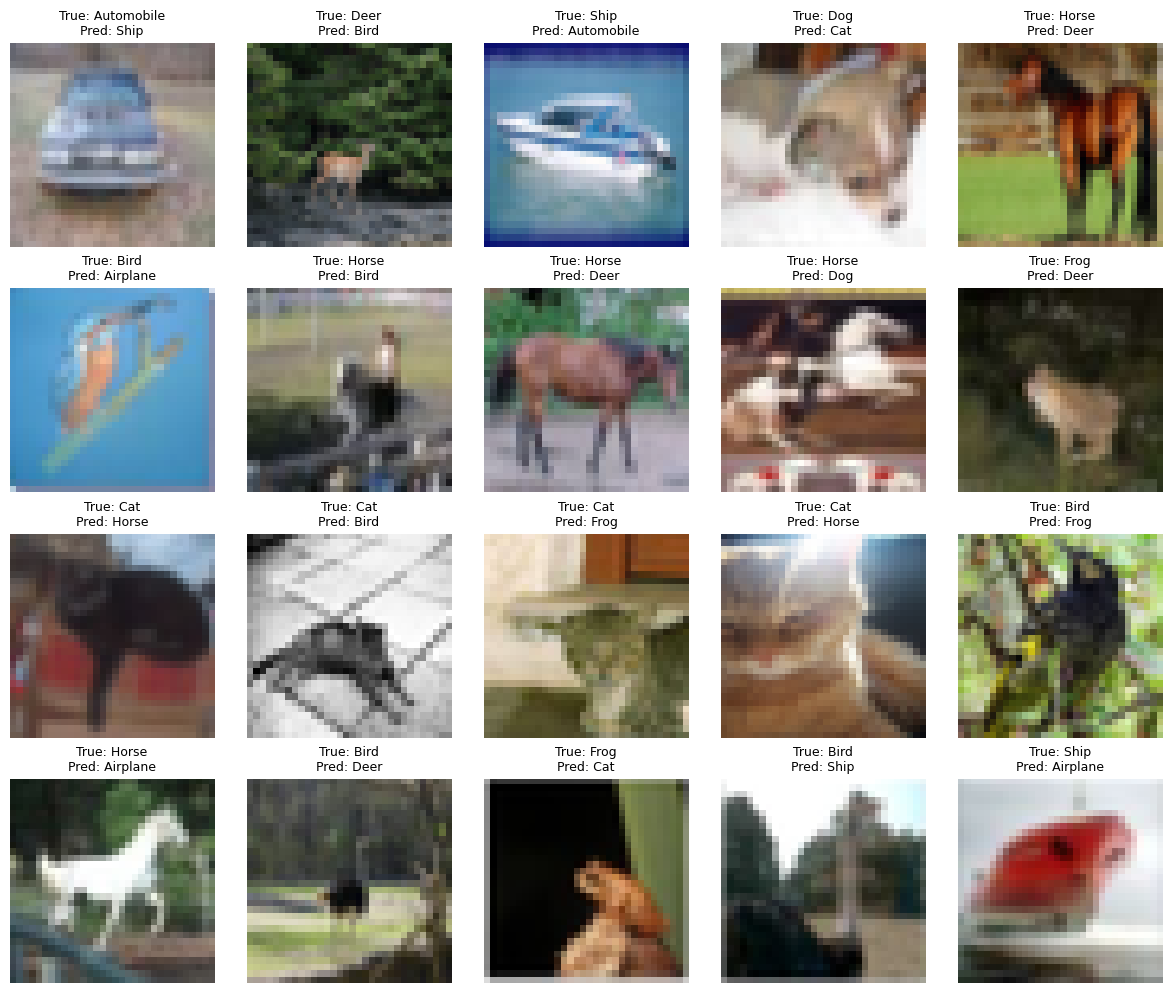

In [16]:
# Show a small set of misclassified test images.
wrong_idx = np.where(y_true != y_pred)[0]
rng = np.random.default_rng(SEED)
n_show = min(20, len(wrong_idx))
chosen = rng.choice(wrong_idx, size=n_show, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
for ax, idx in zip(axes.flat, chosen):
    ax.imshow(x_test_raw[idx])
    ax.set_title(
        f'True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}',
        fontsize=9
    )
    ax.axis('off')

for ax in axes.flat[n_show:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('misclassified_images.png', dpi=180, bbox_inches='tight')
plt.show()

## 8. Lightweight Hyperparameter Study

The required hyperparameters are investigated with short 2-epoch comparisons to keep compute usage low. These runs are **quick comparisons**, not full training runs. The official test set is not used here.

The study compares:
- Learning rate: 0.001 vs 0.0001
- Batch size: 32 vs 64
- Optimizer: Adam vs SGD
- Dense units: 128 vs 256
- Frozen base vs partial fine-tuning

The epoch-count comparison is reported from the main training curve rather than running another expensive pair of full experiments.

In [17]:
QUICK_EPOCHS = 2

def quick_model(dense_units=256, optimizer_name='adam', learning_rate=1e-3, partial_finetune=False):
    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    if partial_finetune:
        base.trainable = True
        for layer in base.layers[:-FINE_TUNE_LAYERS]:
            layer.trainable = False
        for layer in base.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False
    else:
        base.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    m = Model(inputs, outputs)

    if optimizer_name.lower() == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    m.compile(opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def quick_run(label, **kwargs):
    tf.keras.backend.clear_session()
    m = quick_model(**kwargs)
    h = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=QUICK_EPOCHS,
        verbose=0
    )
    best_val = max(h.history['val_accuracy']) * 100
    print(f'{label}: best validation accuracy = {best_val:.2f}%')
    del m
    return best_val

quick_results = []

# Learning rate
for lr in [1e-3, 1e-4]:
    acc = quick_run(f'Learning rate {lr}', learning_rate=lr)
    quick_results.append(['Learning Rate', str(lr), acc])

# Batch size — rebuild only the datasets; no test data is touched.
for bs in [32, 64]:
    train_ds_bs = make_dataset(x_train_raw, y_train, training=True, batch_size=bs)
    val_ds_bs = make_dataset(x_val_raw, y_val, training=False, batch_size=bs)
    tf.keras.backend.clear_session()
    m = quick_model()
    h = m.fit(train_ds_bs, validation_data=val_ds_bs, epochs=QUICK_EPOCHS, verbose=0)
    acc = max(h.history['val_accuracy']) * 100
    print(f'Batch size {bs}: best validation accuracy = {acc:.2f}%')
    quick_results.append(['Batch Size', str(bs), acc])
    del m

# Optimizer
for opt_name in ['adam', 'sgd']:
    acc = quick_run(f'Optimizer {opt_name}', optimizer_name=opt_name)
    quick_results.append(['Optimizer', opt_name.upper(), acc])

# Dense units
for units in [128, 256]:
    acc = quick_run(f'Dense units {units}', dense_units=units)
    quick_results.append(['Dense Units', str(units), acc])

# Frozen vs partial fine-tuning
for partial in [False, True]:
    label = 'Partial' if partial else 'All Frozen'
    acc = quick_run(label, partial_finetune=partial, learning_rate=1e-4 if partial else 1e-3)
    quick_results.append(['Frozen Layers', label, acc])

print('\nQuick hyperparameter study complete.')

Learning rate 0.001: best validation accuracy = 87.96%
Learning rate 0.0001: best validation accuracy = 88.08%
Batch size 32: best validation accuracy = 88.62%
Batch size 64: best validation accuracy = 88.08%
Optimizer adam: best validation accuracy = 88.20%
Optimizer sgd: best validation accuracy = 87.86%
Dense units 128: best validation accuracy = 88.76%
Dense units 256: best validation accuracy = 88.28%
All Frozen: best validation accuracy = 88.74%
Partial: best validation accuracy = 90.24%

Quick hyperparameter study complete.


,Hyperparameter,Setting,Best Validation Accuracy (%)
0,Learning Rate,0.001,87.959999
1,Learning Rate,0.0001,88.080001
2,Batch Size,32,88.620001
3,Batch Size,64,88.080001
4,Optimizer,ADAM,88.200003
5,Optimizer,SGD,87.860000
6,Dense Units,128,88.760000
7,Dense Units,256,88.279998
8,Frozen Layers,All Frozen,88.739997
9,Frozen Layers,Partial,90.240002


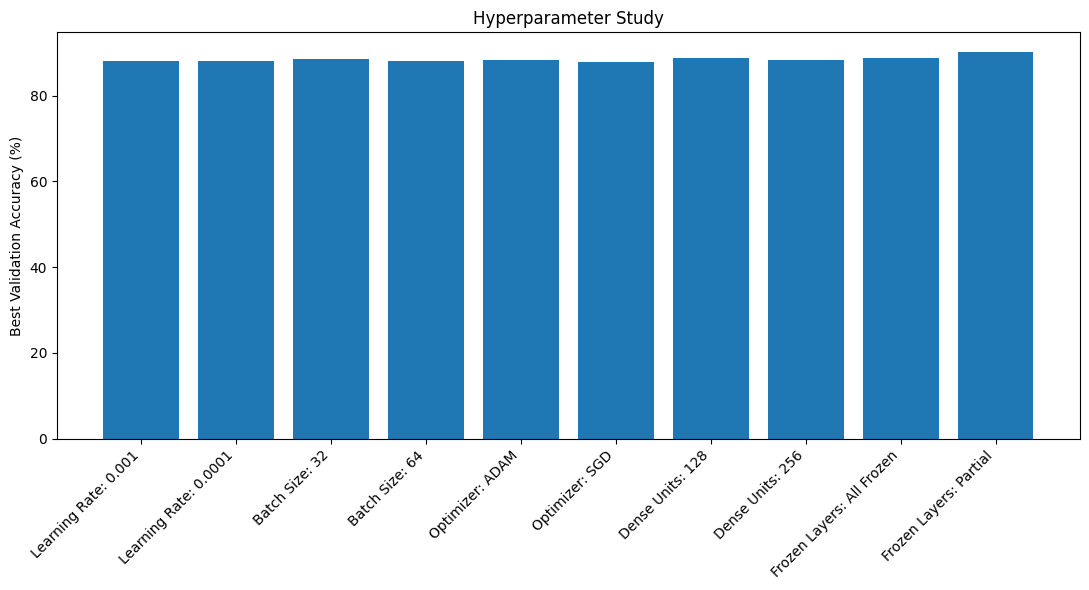

In [20]:
import pandas as pd

quick_df = pd.DataFrame(
    quick_results,
    columns=['Hyperparameter', 'Setting', 'Best Validation Accuracy (%)']
)
display(quick_df)

plt.figure(figsize=(11, 6))
labels = quick_df['Hyperparameter'] + ': ' + quick_df['Setting']
plt.bar(labels, quick_df['Best Validation Accuracy (%)'])
plt.ylabel('Best Validation Accuracy (%)')
plt.title('Hyperparameter Study')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('hyperparameter_study.png', dpi=180, bbox_inches='tight')
plt.show()

quick_df.to_csv('hyperparameter_results.csv', index=False)

## 9. Final Results Summary

The following values are generated directly from the final model and can be transferred into the laboratory report.

In [21]:
best_head_val = max(history_head.history['val_accuracy']) * 100
best_ft_val = max(history_ft.history['val_accuracy']) * 100
final_train_acc = history_ft.history['accuracy'][-1] * 100
total_time = head_time + finetune_time
total_params = model.count_params()
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
non_trainable_params = total_params - trainable_params

print('=' * 60)
print('FINAL RESULTS')
print('=' * 60)
print(f'Final fine-tuning training accuracy : {final_train_acc:.2f}%')
print(f'Best frozen-base validation accuracy: {best_head_val:.2f}%')
print(f'Best fine-tuning validation accuracy: {best_ft_val:.2f}%')
print(f'Testing accuracy                    : {test_accuracy*100:.2f}%')
print(f'Macro precision                     : {precision_macro:.4f}')
print(f'Macro recall                        : {recall_macro:.4f}')
print(f'Macro F1-score                      : {f1_macro:.4f}')
print(f'Total training time                 : {total_time/60:.2f} min')
print(f'Total parameters                    : {total_params:,}')
print(f'Trainable parameters                : {trainable_params:,}')
print(f'Non-trainable parameters            : {non_trainable_params:,}')
print('=' * 60)

FINAL RESULTS
Final fine-tuning training accuracy : 99.77%
Best frozen-base validation accuracy: 89.18%
Best fine-tuning validation accuracy: 90.82%
Testing accuracy                    : 90.67%
Macro precision                     : 0.9076
Macro recall                        : 0.9067
Macro F1-score                      : 0.9069
Total training time                 : 8.33 min
Total parameters                    : 24,114,826
Trainable parameters                : 4,986,634
Non-trainable parameters            : 19,128,192


In [38]:
import os
import zipfile

image_files = [
    "sample_images.png",
    "accuracy_plot.png",
    "loss_plot.png",
    "finetune_accuracy_plot.png",
    "finetune_loss_plot.png",
    "confusion_matrix.png",
    "misclassified_images.png",
    "hyperparameter_study.png",
]

zip_path = "/kaggle/working/images.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for filename in image_files:
        filepath = os.path.join("/kaggle/working", filename)

        if os.path.isfile(filepath):
            zipf.write(filepath, arcname=filename)
            print(f"Added: {filepath}")
        else:
            print(f"NOT FOUND: {filepath}")

print("\nCreated:", zip_path)
print("Size:", os.path.getsize(zip_path) / 1024, "KB")

with zipfile.ZipFile(zip_path, "r") as zipf:
    print("\nContents:")
    for name in zipf.namelist():
        print(" -", name)

Added: /kaggle/working/sample_images.png
Added: /kaggle/working/accuracy_plot.png
Added: /kaggle/working/loss_plot.png
Added: /kaggle/working/finetune_accuracy_plot.png
Added: /kaggle/working/finetune_loss_plot.png
Added: /kaggle/working/confusion_matrix.png
Added: /kaggle/working/misclassified_images.png
Added: /kaggle/working/hyperparameter_study.png

Created: /kaggle/working/images.zip
Size: 598.5458984375 KB

Contents:
 - sample_images.png
 - accuracy_plot.png
 - loss_plot.png
 - finetune_accuracy_plot.png
 - finetune_loss_plot.png
 - confusion_matrix.png
 - misclassified_images.png
 - hyperparameter_study.png
